In [1]:
from google.colab import files
files.upload()  # choose your kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets list -s "cats vs dogs"

ref                                                    title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset             Cats-vs-Dogs                                    825979578  2020-03-12 05:34:30.730000         113280        996  0.875            
biaiscience/dogs-vs-cats                               Dogs vs Cats                                    856265363  2017-12-05 14:03:33.210000          32880        368  0.4375           
pybear/cats-vs-dogs                                    Cats -- VS -- Dogs                              825979578  2020-10-18 13:55:30.950000           3353        106  0.625            
sujaykapadnis/cats-vs-dogs                             Cats Vs Dogs   

In [3]:
!kaggle datasets download -d salader/dogsvscats
!unzip -q dogsvscats.zip -d data

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:08<00:00, 135MB/s]



In [4]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential,regularizers
from keras.layers import Dense,Flatten,Conv2D,MaxPool2D,BatchNormalization, Activation,Dropout

In [6]:
# Generators:
train_ds = keras.utils.image_dataset_from_directory(
  directory = '/content/train',
  labels ='inferred',
  label_mode = 'int',
  batch_size = 32,
  image_size =(256,256)
)

test_ds = keras.utils.image_dataset_from_directory(
  directory = '/content/test',
  labels ='inferred',
  label_mode = 'int',
  batch_size = 32,
  image_size =(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [7]:
# Normalize:
def process(image,label):
  image = tf.cast(image/255. ,tf.float32)
  return image,label

train_ds = train_ds.map(process)
validation_ds = test_ds.map(process)

In [8]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [9]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='same',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPool2D(pool_size=(2,2),strides=2,padding='valid'))
model.add(Flatten())
model.add(Dense(128,activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(64,activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dropout(0.4))
model.add(Dense(32,activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 126, 126, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,729 (56.65 MB)

 Trainable params: 14,849,537 (56.65 MB)

 Non-trainable params: 192 (768.00 B)

In [11]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [12]:
history = model.fit(train_ds,epochs=20,validation_data=validation_ds,callbacks=[early_stop])

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 67s 88ms/step - accuracy: 0.5545 - loss: 1.1244 - val_accuracy: 0.5840 - val_loss: 0.8190
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 86ms/step - accuracy: 0.6391 - loss: 0.7703 - val_accuracy: 0.6694 - val_loss: 0.7367
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.7045 - loss: 0.6961 - val_accuracy: 0.7204 - val_loss: 0.6785
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.7552 - loss: 0.6226 - val_accuracy: 0.7564 - val_loss: 0.6060
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.7885 - loss: 0.5627 - val_accuracy: 0.7980 - val_loss: 0.5626
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.8098 - loss: 0.5285 - val_accuracy: 0.7694 - val_loss: 0.5881
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 89ms/step - accuracy: 0.8259 - loss: 0.4969 - val_accuracy: 0.7668 - val_loss: 0.5615
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.8393 - loss: 0.4753 - 

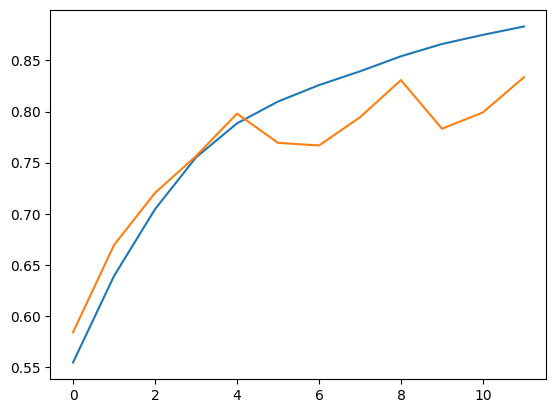

In [13]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

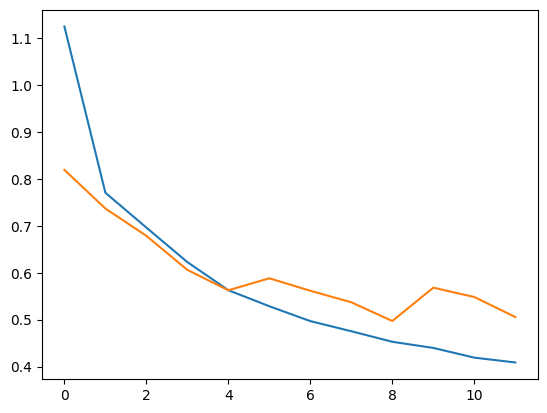

In [14]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [15]:
import cv2

In [16]:
test_img = cv2.imread('/content/images.jfif')

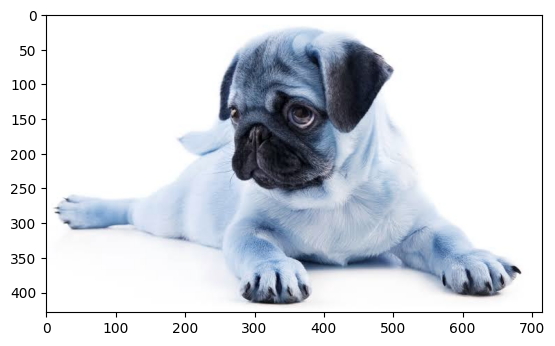

In [17]:
plt.imshow(test_img)

In [18]:
test_img.shape

(429, 715, 3)

In [19]:
test_img=cv2.resize(test_img,(256,256))

In [20]:
test_img = test_img / 255.0

In [21]:
test_input=test_img.reshape(1,256,256,3)

In [22]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


array([[0.3763202]], dtype=float32)

In [23]:
test_img1 = cv2.imread('/content/white-cat-breeds-kitten-in-grass-67bf648a54a3b.avif')

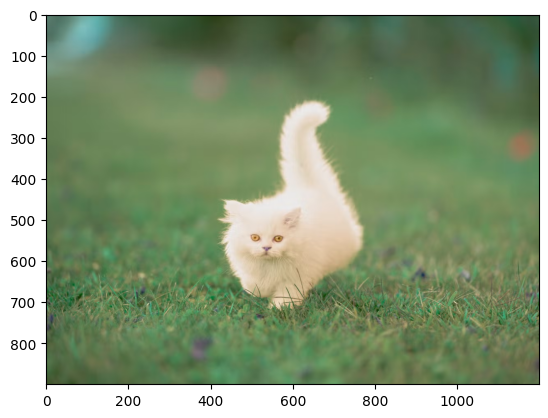

In [24]:
plt.imshow(test_img1)

In [25]:
test_img1.shape

(900, 1200, 3)

In [26]:
test_img1=cv2.resize(test_img1,(256,256))

In [27]:
test_img = test_img / 255.0

In [28]:
test_input1=test_img1.reshape(1,256,256,3)

In [29]:
model.predict(test_input1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step


array([[1.]], dtype=float32)

In [38]:
def predict_image(test_inputs):
    result = model.predict(test_inputs)

    if result[0][0] > 0.5:
        return "Cat"
    else:
        return "Dog"

In [39]:
print(predict_image(test_input))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Dog


In [40]:
print(predict_image(test_input1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Cat
